
# 🎓 Recommendation System for Student Performance

## 📚 Table of Contents

- SECTION 0 — Setup & Imports
- SECTION 1 — Preprocessing
- SECTION 2 — Epiplexity Functions
- SECTION 3 — Model Definitions
- SECTION 4 — Evaluation Helpers
- SECTION 5 — Binary Dataset Pipeline
    - Generate Synthetic
    - 📌 STAGE 1: 20% of Course
    - 📌 STAGE 2: 50% of Course
    - 🏆 Final Comparison
- SECTION 6 — Multi-class Dataset Pipeline


# SECTION 0 — Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy


from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import BorderlineSMOTE

# ── CONFIG ──────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
CHUNK_SIZE = 5
EPI_THRESHOLD = 0.0001
MIN_RECALL_W  = 0.75   # minimum recall for W class (early warning target)

import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings(
    "ignore",
    category=ConvergenceWarning
)


In [2]:
ALL_FEATURES = [
    "Quiz01 [10]",
    "Assignment01 [8]",
    "Midterm Exam [20]",
    "Assignment02 [12]",
    "Assignment03 [25]"
]

STAGE1_FEATURES = [
    "Quiz01 [10]",
    "Assignment01 [8]"
]

STAGE2_FEATURES = [
    "Quiz01 [10]",
    "Assignment01 [8]",
    "Midterm Exam [20]",
    "Assignment02 [12]"
]

TARGET = "Class"


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# SECTION 1 — Preprocessing

In [4]:
# ── Load datasets ───────────────────────────────────────────────────────
binary_path = "/content/drive/MyDrive/Course/thesis/Student Performance Prediction-Binary.csv"
multi_path  = "/content/drive/MyDrive/Course/thesis/Student Performance Prediction-Multi.csv"

df_binary = pd.read_csv(binary_path)
df_multi  = pd.read_csv(multi_path)

print("=" * 55)
print("BINARY dataset  →  shape:", df_binary.shape)
print(df_binary[TARGET].value_counts().to_string())
ratio_b = df_binary[TARGET].value_counts()
print(f"Imbalance ratio: {ratio_b.max() / ratio_b.min():.1f} : 1")

print()
print("=" * 55)
print("MULTI dataset   →  shape:", df_multi.shape)
print(df_multi[TARGET].value_counts().to_string())
ratio_m = df_multi[TARGET].value_counts()
print(f"Imbalance ratio: {ratio_m.max() / ratio_m.min():.1f} : 1")

BINARY dataset  →  shape: (486, 10)
Class
G    465
W     21
Imbalance ratio: 22.1 : 1

MULTI dataset   →  shape: (486, 10)
Class
G    419
F     59
W      8
Imbalance ratio: 52.4 : 1


## EDA (Exploratory Data Analysis)

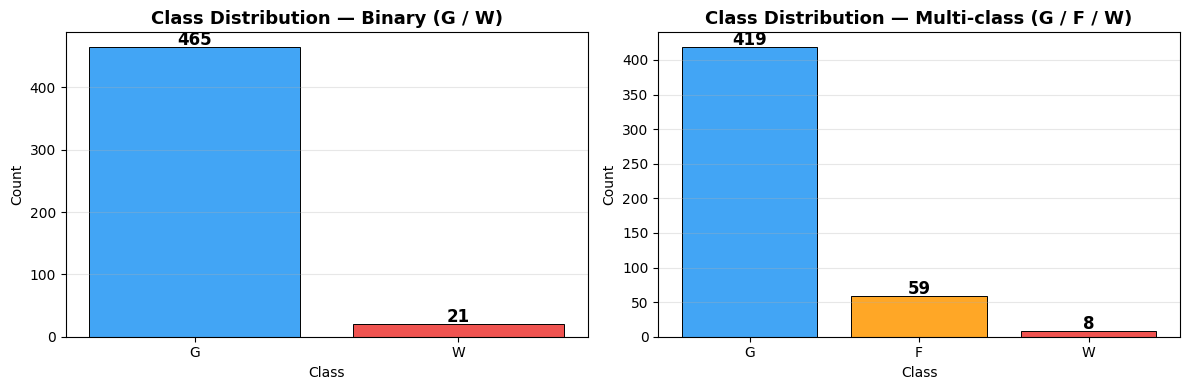

In [5]:
# ── Visualise class distribution ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, title in zip(axes,
                          [df_binary, df_multi],
                          ["Binary (G / W)", "Multi-class (G / F / W)"]):
    counts = df[TARGET].value_counts()
    colors = ['#42A5F5' if c != 'W' else '#EF5350'
              for c in counts.index]
    if 'F' in counts.index:
        colors = ['#42A5F5' if c == 'G' else
                  '#FFA726' if c == 'F' else '#EF5350'
                  for c in counts.index]
    bars = ax.bar(counts.index, counts.values, color=colors,
                  edgecolor='black', linewidth=0.7)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 3, str(val),
                ha='center', fontweight='bold', fontsize=12)
    ax.set_title(f"Class Distribution — {title}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Class"); ax.set_ylabel("Count")
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
#Missing values
print("Missing Values in Binary Dataset:")
print(df_binary.isnull().sum())

print("\nMissing Values in Multi Dataset:")
print(df_multi.isnull().sum())

Missing Values in Binary Dataset:
Student ID           0
Quiz01 [10]          0
Assignment01 [8]     0
Midterm Exam [20]    0
Assignment02 [12]    0
Assignment03 [25]    0
Final Exam [35]      0
Course Grade         0
Total [100]          0
Class                0
dtype: int64

Missing Values in Multi Dataset:
Student ID           0
Quiz01 [10]          0
Assignment01 [8]     0
Midterm Exam [20]    0
Assignment02 [12]    0
Assignment03 [25]    0
Final Exam [35]      0
Course Grade         0
Total [100]          0
Class                0
dtype: int64


In [7]:
#Check duplicate
print("Duplicate Rows in Binary Dataset:", df_binary.duplicated().sum())
print("Duplicate Rows in Multi Dataset:", df_multi.duplicated().sum())

Duplicate Rows in Binary Dataset: 0
Duplicate Rows in Multi Dataset: 0


##Feature Distributions

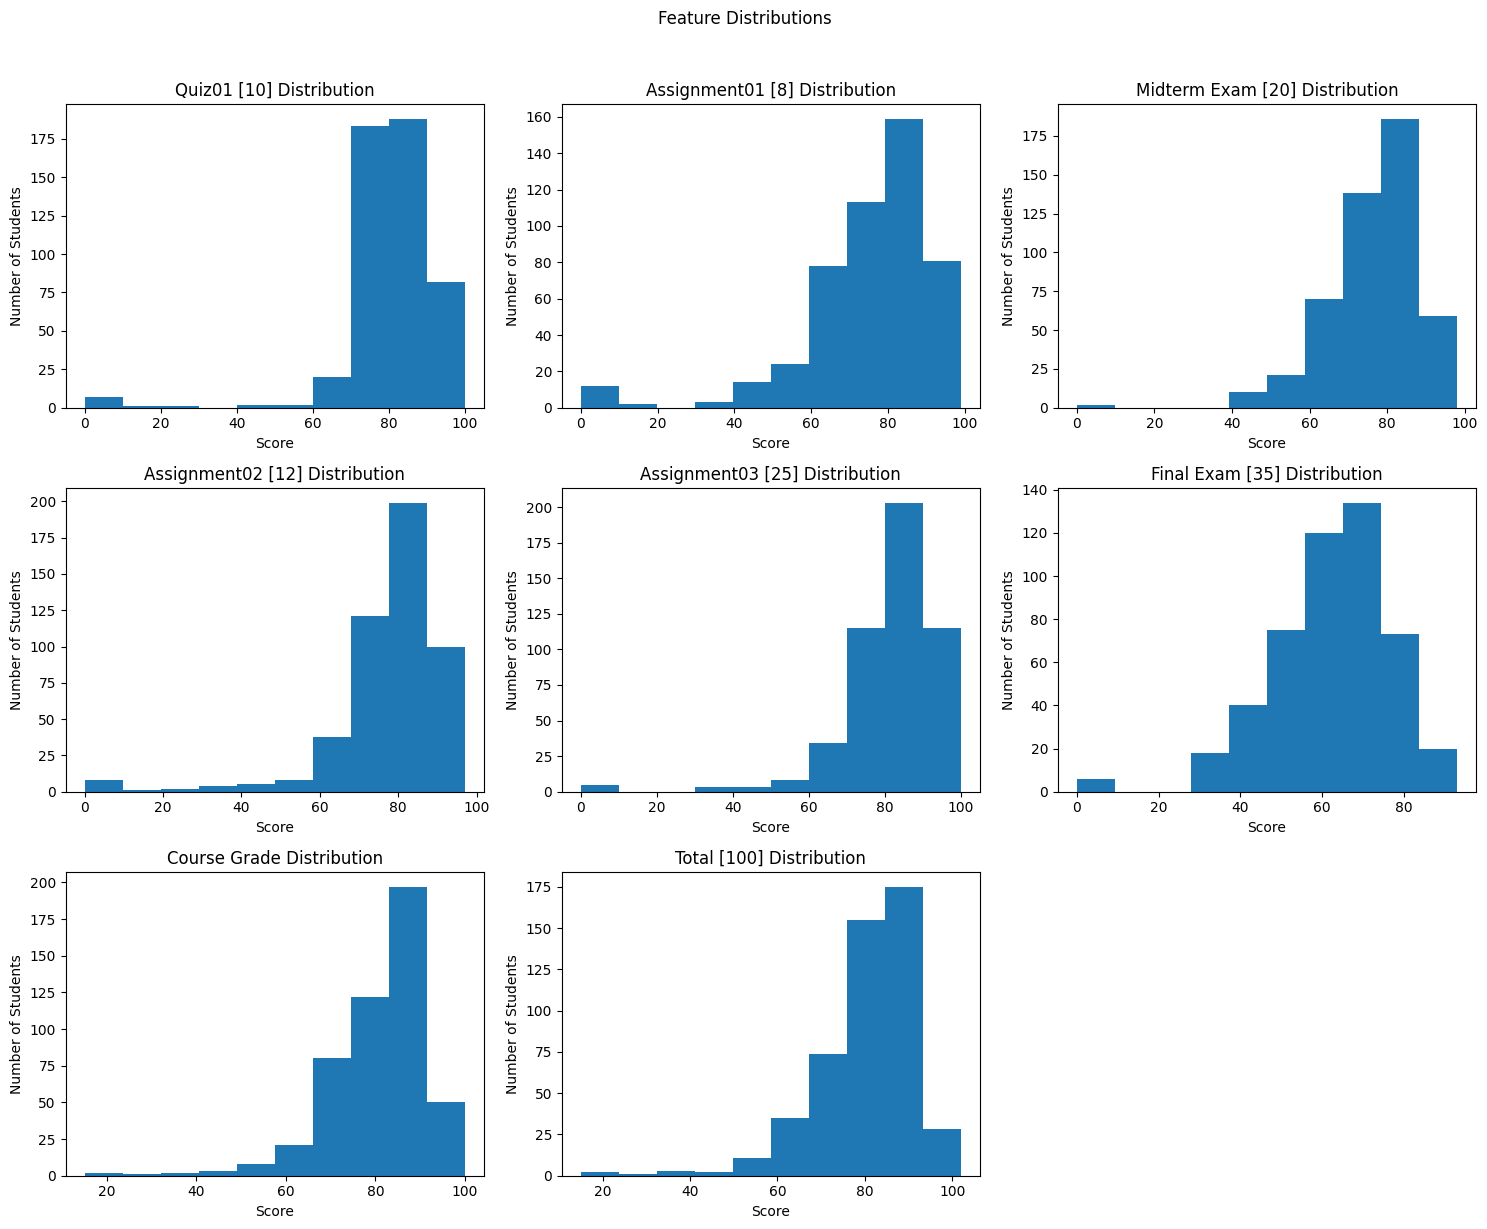

In [8]:
def plot_feature_distributions(df, title):
    features = df.drop(columns=["Student ID", "Class"]).columns
    n_features = len(features)
    n_cols = 3 # Adjust as needed for desired layout
    n_rows = (n_features + n_cols - 1) // n_cols

    plt.figure(figsize=(n_cols * 5, n_rows * 4))
    for i, feature in enumerate(features):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.hist(df[feature], bins=10) # Using default bins, can be customized
        plt.title(f'{feature} Distribution')
        plt.xlabel('Score')
        plt.ylabel('Number of Students')
    plt.suptitle(title, y=1.02) # Adjust suptitle position
    plt.tight_layout()
    plt.show()

plot_feature_distributions(df_binary,"Feature Distributions")

##Check outliers

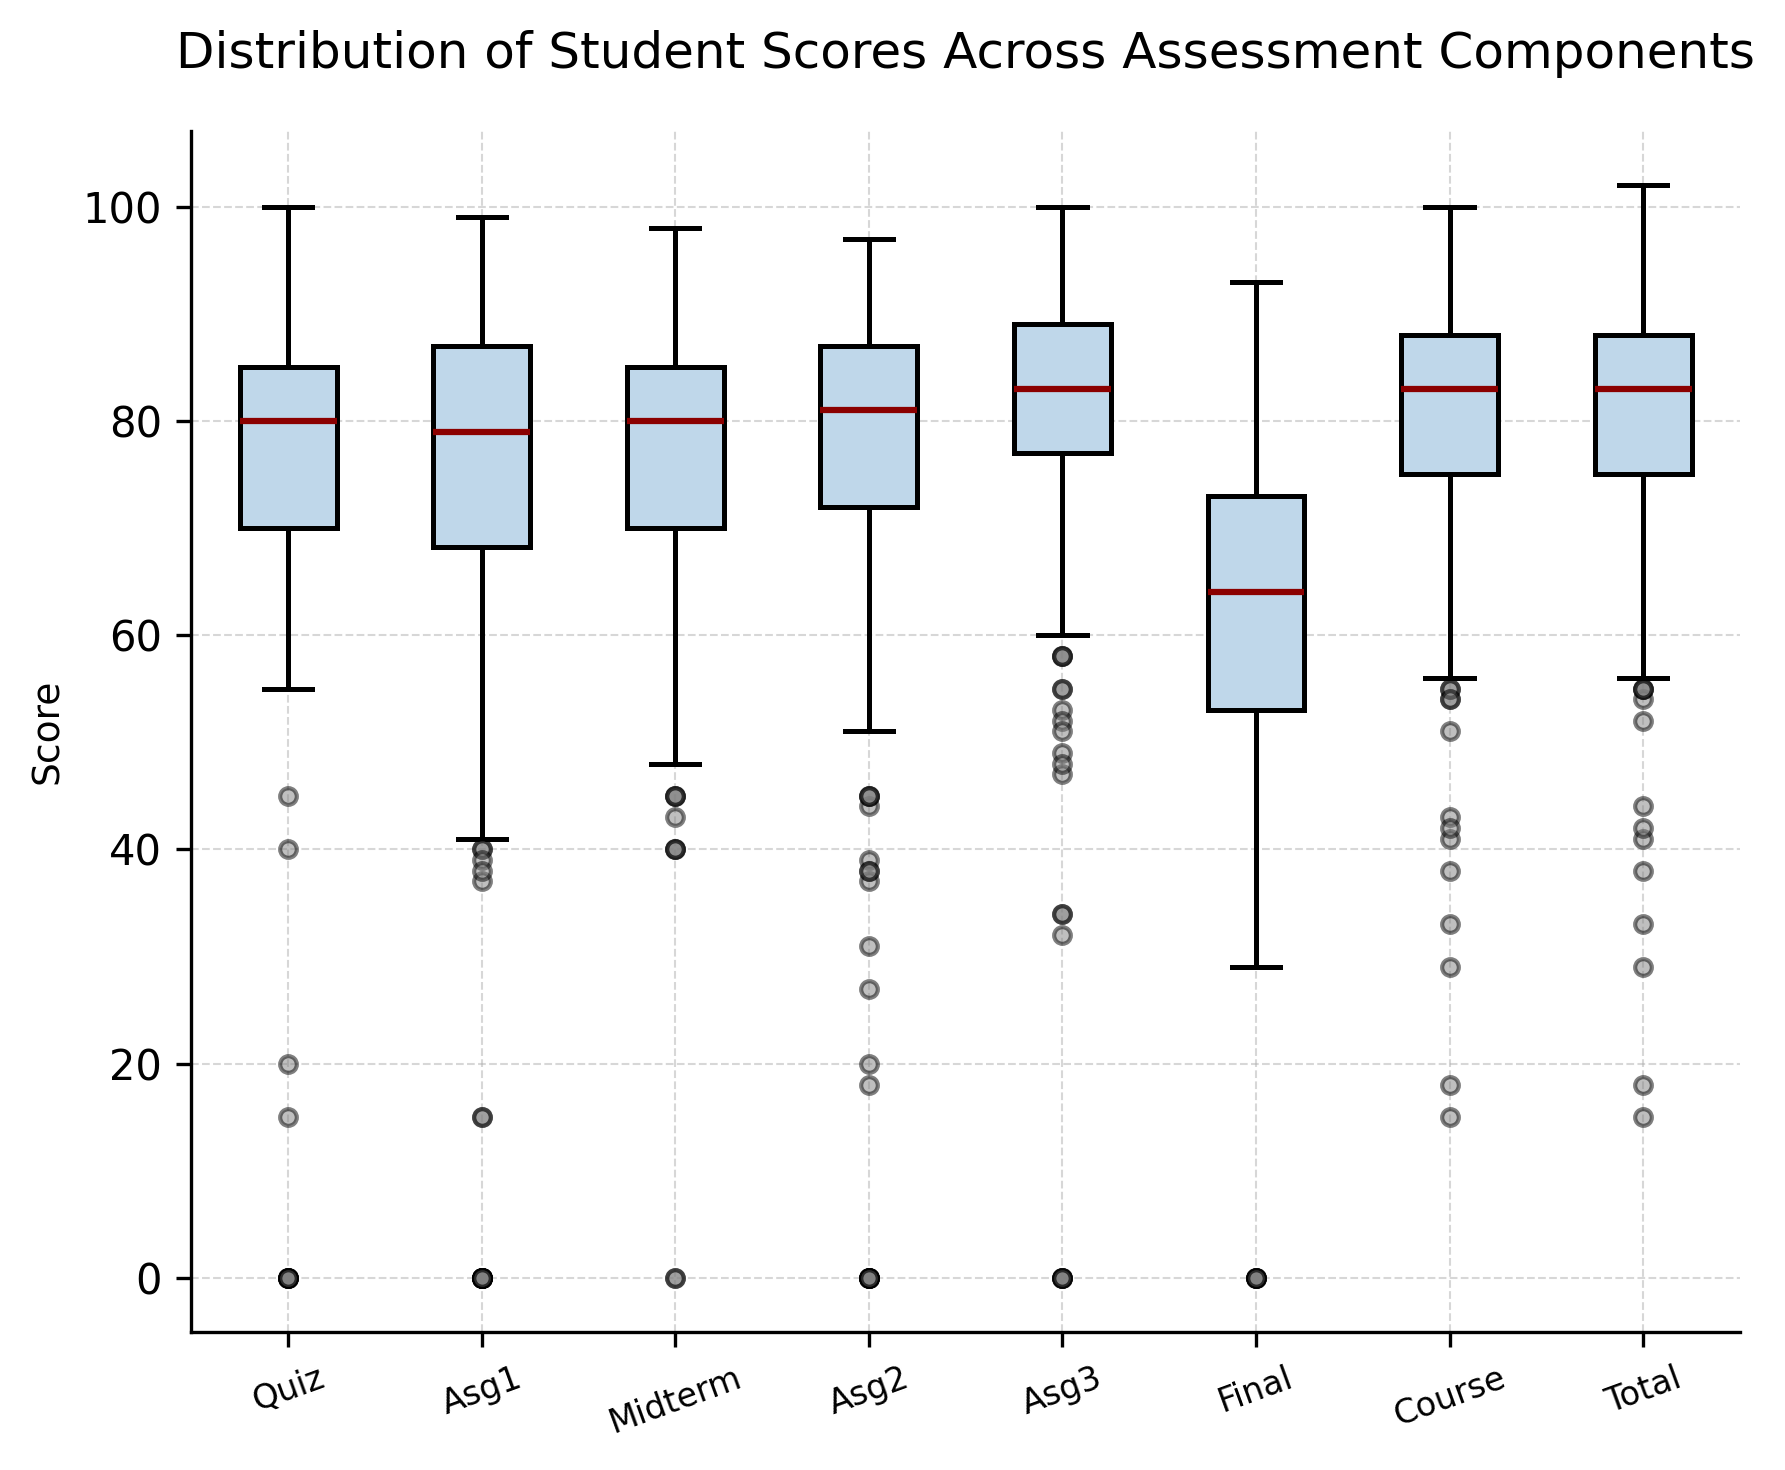

In [9]:
# Distribution of Student Scores Across Assessment Components
labels = [
    'Quiz',
    'Asg1',
    'Midterm',
    'Asg2',
    'Asg3',
    'Final',
    'Course',
    'Total'
]

plt.style.use('default')

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

df_binary.drop(columns=["Student ID", "Class"]).boxplot(
    ax=ax,
    patch_artist=True,

    # Box style
    boxprops=dict(
        facecolor="#BFD7EA",
        linewidth=1.2
    ),

    # Median line
    medianprops=dict(
        color="darkred",
        linewidth=1.5
    ),

    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),

    # Outlier style
    flierprops=dict(
        marker='o',
        markersize=4,
        markerfacecolor='gray',
        markeredgecolor='black',
        alpha=0.5
    )
)

# Set custom labels
ax.set_xticklabels(labels, rotation=20, fontsize=8)

ax.set_title(
    "Distribution of Student Scores Across Assessment Components",
    fontsize=12,
    pad=15
)

ax.set_ylabel("Score", fontsize=9)
ax.set_xlabel("")

plt.yticks(fontsize=10)

# Light grid
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

# Cleaner frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.show()

##Correlation

In [10]:
def plot_correlation_heatmap(df, title):
    plt.figure(figsize=(8,6))
    plt.imshow(df.drop(columns=["Student ID","Class"]).corr(), aspect='auto')
    plt.title(title)
    plt.colorbar()
    plt.xticks(range(len(df.drop(columns=["Student ID","Class"]).columns)),
           df.drop(columns=["Student ID","Class"]).columns, rotation=90)
    plt.yticks(range(len(df.drop(columns=["Student ID","Class"]).columns)),
           df.drop(columns=["Student ID","Class"]).columns)
    plt.show()

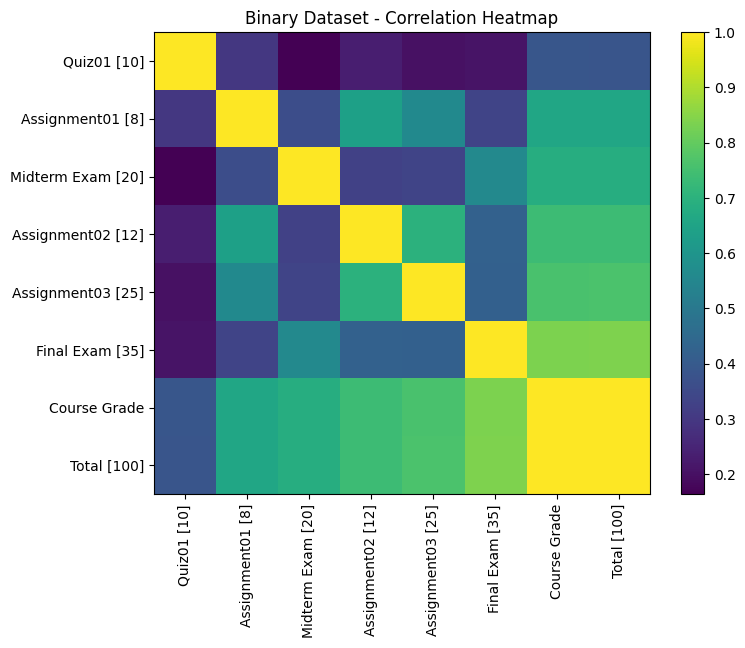

In [11]:
plot_correlation_heatmap(df_binary, "Binary Dataset - Correlation Heatmap")

=========================================================
## DATA PREPARATION FUNCTION
=========================================================


In [12]:
def prepare_dataset(
    df,
    feature_cols,
    target_col,
    dataset_name='DATASET',
    test_size=0.2,
    random_state=42
):

    df = df.copy()

    le = None

    # -----------------------------------------
    # LABEL ENCODING
    # -----------------------------------------

    if dataset_name.upper() == "BINARY":

        le = LabelEncoder()

        df[target_col] = le.fit_transform(
            df[target_col]
        )

    elif dataset_name.upper() == "MULTI-CLASS":

        mapping = {
            "G": 0,
            "W": 1,
            "F": 2
        }

        df[target_col] = df[target_col].map(mapping)

    # -----------------------------------------
    # FEATURES + TARGET
    # -----------------------------------------

    X = df[feature_cols].values
    y = df[target_col].values

    # -----------------------------------------
    # SCALER
    # -----------------------------------------

    #scaler = StandardScaler()
    #X_scaled = scaler.fit_transform(X)

    # -----------------------------------------
    # TRAIN / TEST SPLIT
    # -----------------------------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        random_state=random_state
    )

    # -----------------------------------------
    # SHOW DISTRIBUTION
    # -----------------------------------------
    print("Train:", Counter(y_train))
    print("Test :", Counter(y_test))

    return (
        X_train,
        X_test,
        y_train,
        y_test,
        le,
        scaler:=None
    )

# SECTION 2 — Imbalance Handling

## Epiplexity function

In [13]:
class EpiplexityTracker:

    def __init__(self):
        self.losses = []

    def add(self, loss):
        self.losses.append(loss)

    def compute(self):

        if len(self.losses) == 0:
            return 0

        final_loss = self.losses[-1]

        epi = np.sum(
            np.array(self.losses) - final_loss
        )

        return float(epi)



In [14]:
def compute_epiplexity(
    X_train,
    y_train,
    epochs=30
):

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)

    probe_model = LogisticRegression(
        max_iter=1,
        warm_start=True,
        solver='saga',
        class_weight='balanced',
        random_state=RANDOM_STATE
    )

    # save loss each epoch
    tracker = EpiplexityTracker()

    for epoch in range(epochs):

        probe_model.fit(X_train_scaled, y_train)

        probs = probe_model.predict_proba(X_train_scaled)

        eps = 1e-12

        loss = 0

        for i in range(len(y_train)):

            loss -= np.log(
                probs[i, y_train[i]] + eps
            )

        loss /= len(y_train)

        tracker.add(loss)

    epiplexity = tracker.compute()

    return epiplexity

## Generate Synthetic function

In [15]:
def generate_candidates(
    X_train,
    y_train
):

    n_classes = len(np.unique(y_train))
    # =====================================================
    # BINARY
    # =====================================================
    if n_classes == 2:
        sampler = BorderlineSMOTE(
            sampling_strategy=0.15,
            random_state=RANDOM_STATE,
            k_neighbors=1
        )

    # =====================================================
    # MULTICLASS
    # =====================================================
    else:
        sampler = BorderlineSMOTE(
            sampling_strategy={1: 25, 2: 65},
            random_state=RANDOM_STATE,
            k_neighbors=1
        )

    X_resampled, y_resampled = sampler.fit_resample(
        X_train,
        y_train
    )

    n_original = len(X_train)

    # synthetic only
    X_syn = X_resampled[n_original:]
    y_syn = y_resampled[n_original:]

    return X_syn, y_syn


### evaluate synthetic sample

In [16]:
def evaluate_synthetic_samples(
    X_original,
    y_original,
    X_syn,
    y_syn,
    chunk_size=5
):

    print("\n")
    print("=" * 60)
    print("STEP 2 — EVALUATING SYNTHETIC SAMPLES")
    print("=" * 60)

    # baseline epiplexity
    base_epi = compute_epiplexity(
        X_original,
        y_original
    )

    print(f"\nBaseline Epiplexity: {base_epi:.6f}")

    selected_X = []
    selected_y = []

    results = []

    chunk_id = 1

    for start in range(0, len(X_syn), chunk_size):

        end = start + chunk_size

        X_chunk = X_syn[start:end]
        y_chunk = y_syn[start:end]

        # -----------------------------------------
        # temporarily add synthetic samples
        # -----------------------------------------

        X_temp = np.vstack([
            X_original,
            X_chunk
        ])

        y_temp = np.hstack([
            y_original,
            y_chunk
        ])

        # -----------------------------------------
        # train probe model + compute epiplexity
        # -----------------------------------------

        new_epi = compute_epiplexity(
            X_temp,
            y_temp
        )

        gain = new_epi - base_epi

        # -----------------------------------------
        # keep or reject
        # -----------------------------------------

        decision = "REJECT"

        if gain > EPI_THRESHOLD:

            decision = "KEEP"

            selected_X.append(X_chunk)
            selected_y.append(y_chunk)

            base_epi = new_epi

        # -----------------------------------------
        # print results
        # -----------------------------------------

        print("\n")
        print("-" * 50)

        print(f"Chunk #{chunk_id}")
        print(f"Samples: {len(X_chunk)}")

        print(f"Old Epiplexity : {base_epi:.6f}")
        print(f"New Epiplexity : {new_epi:.6f}")
        print(f"Gain            : {gain:.6f}")

        print(f"Decision        : {decision}")

        results.append({
            "chunk": chunk_id,
            "samples": len(X_chunk),
            "new_epiplexity": new_epi,
            "gain": gain,
            "decision": decision
        })

        chunk_id += 1

    results_df = pd.DataFrame(results)

    # =====================================================
    # STEP 3 — BUILD CURATED DATASET
    # =====================================================

    print("\n")
    print("=" * 60)
    print("STEP 3 — BUILD CURATED DATASET")
    print("=" * 60)

    if len(selected_X) > 0:

        selected_X = np.vstack(selected_X)
        selected_y = np.hstack(selected_y)

        X_curated = np.vstack([
            X_original,
            selected_X
        ])

        y_curated = np.hstack([
            y_original,
            selected_y
        ])

    else:

        X_curated = X_original
        y_curated = y_original

    print("\nOriginal Distribution:")
    print(Counter(y_original))

    print("\nSelected Synthetic Samples:")
    print(len(selected_y))

    print("\nFinal Curated Distribution:")
    print(Counter(y_curated))

    return (
        X_curated,
        y_curated,
        results_df
    )

# SECTION 3 — Model Definitions

In [17]:
MODELS = {
    "LR": LogisticRegression(
        max_iter=2000,
        solver='liblinear',
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),

    "RF": RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=RANDOM_STATE
    ),

    "SVM": SVC(
        kernel='rbf',
        probability=True,
        class_weight='balanced',
        random_state=RANDOM_STATE
    )
}

In [18]:
# =========================================================
# TRAINED MODEL REGISTRY
# =========================================================

TRAINED_MODELS = {}

### Model selection

In [19]:
def select_best_model(
    results_df,
    dataset
):

    # =====================================
    # FILTER SCENARIO
    # =====================================

    subset = results_df[
        (results_df["Dataset"] == dataset)
    ].copy()

    # =====================================
    # SORT PRIORITY
    # =====================================

    subset = subset.sort_values(

        by=[
            "Weak_Recall",
            "Accuracy",
            "Macro_F1"
        ],

        ascending=False

    )

    # =====================================
    # BEST MODEL
    # =====================================

    best_row = subset.iloc[0]

    return best_row

# SECTION 4 — Evaluation Helpers

In [20]:
def evaluate_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="MODEL",
):

    print("\n")
    print("=" * 60)
    print(model_name)
    print("=" * 60)



    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # =====================================================
    # METRICS
    # =====================================================

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    macro_f1 = f1_score(
        y_test,
        y_pred,
        average='macro'
    )

    # =====================================================
    # CLASSIFICATION REPORT
    # =====================================================

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    # weak class = 1
    recall_w = report.get('1', {}).get('recall', 0.0)
    precision_w = report.get('1', {}).get('precision', 0.0)
    f1_w = report.get('1', {}).get('f1-score', 0.0)

    # =====================================================
    # PRINT RESULTS
    # =====================================================

    print(f"Accuracy    : {accuracy:.4f}")
    print(f"Macro-F1    : {macro_f1:.4f}")
    print(f"Recall      : {recall_w:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    return {
        "Model": model_name,
        "Trained_Model": model,
        "Macro_F1": macro_f1,
        "Accuracy": accuracy,
        "Weak_Recall": recall_w
    }

# SECTION 5 — Binary Dataset Pipeline

## ALL FEATURE

In [21]:
DATASET_NAME = "BINARY"
df_active    = df_binary
df_active.head()

X_train, X_test, y_train, y_test, le_s1, scaler_s1 = prepare_dataset(
    df=df_active,
    feature_cols=ALL_FEATURES,
    target_col=TARGET,
    dataset_name=DATASET_NAME,
    test_size=0.3,
    random_state=42
)

Train: Counter({np.int64(0): 325, np.int64(1): 15})
Test : Counter({np.int64(0): 140, np.int64(1): 6})


### Generate synthetic

In [22]:
X_syn, y_syn = generate_candidates(
    X_train,
    y_train
)

print("=" * 60)
print("STEP 1 — GENERATE SYNTHETIC CANDIDATES")
print("=" * 60)

print("\nSynthetic samples generated:")
print(len(X_syn))

print("\nSynthetic class distribution:")
print(Counter(y_syn))

X_curated, y_curated, evaluation_results = (
    evaluate_synthetic_samples(
        X_train,
        y_train,
        X_syn,
        y_syn,
        chunk_size=CHUNK_SIZE
    )
)

print("\n")
print("=" * 60)
print("SYNTHETIC SAMPLE EVALUATION RESULTS")
print("=" * 60)

print(evaluation_results)


STEP 1 — GENERATE SYNTHETIC CANDIDATES

Synthetic samples generated:
33

Synthetic class distribution:
Counter({np.int64(1): 33})


STEP 2 — EVALUATING SYNTHETIC SAMPLES

Baseline Epiplexity: 0.405293


--------------------------------------------------
Chunk #1
Samples: 5
Old Epiplexity : 0.405293
New Epiplexity : 0.244853
Gain            : -0.160439
Decision        : REJECT


--------------------------------------------------
Chunk #2
Samples: 5
Old Epiplexity : 0.405293
New Epiplexity : 0.268359
Gain            : -0.136934
Decision        : REJECT


--------------------------------------------------
Chunk #3
Samples: 5
Old Epiplexity : 0.405293
New Epiplexity : 0.136415
Gain            : -0.268878
Decision        : REJECT


--------------------------------------------------
Chunk #4
Samples: 5
Old Epiplexity : 0.405293
New Epiplexity : 0.183119
Gain            : -0.222174
Decision        : REJECT


--------------------------------------------------
Chunk #5
Samples: 5
Old Epiplexity

In [23]:
all_result = []

# =========================================================
# TRAINING ON ORIGINAL DATASET
# =========================================================

print("\n")
print("=" * 60)
print("TRAINING ON ORIGINAL DATASET")
print("=" * 60)

for model_name, model in MODELS.items():

    results = evaluate_model(
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        model_name=f"{model_name} (Original)"
    )

    results["Dataset"] = "Original"
    results["Model"] = model_name

    all_result .append(results)

# =========================================================
# TRAINING ON CURATED DATASET
# =========================================================

print("\n")
print("=" * 60)
print("TRAINING ON CURATED DATASET")
print("=" * 60)

for model_name, model in MODELS.items():

    results = evaluate_model(
        model,
        X_curated,
        y_curated,
        X_test,
        y_test,
        model_name=f"{model_name} (Curated)"
    )

    results["Dataset"] = "Curated"
    results["Model"] = model_name

    all_result .append(results)

# =========================================================
# FINAL COMPARISON
# =========================================================

results_df = pd.DataFrame(all_result)

results_df = results_df[
    [
        "Dataset",
        "Model",
        "Macro_F1",
        "Accuracy",
        "Weak_Recall"
    ]
]

print("\n")
print("=" * 60)
print("FINAL COMPARISON")
print("=" * 60)

print(results_df)



TRAINING ON ORIGINAL DATASET


LR (Original)
Accuracy    : 0.9726
Macro-F1    : 0.8678
Recall      : 1.0000

Confusion Matrix:
[[136   4]
 [  0   6]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99       140
           1       0.60      1.00      0.75         6

    accuracy                           0.97       146
   macro avg       0.80      0.99      0.87       146
weighted avg       0.98      0.97      0.98       146



RF (Original)
Accuracy    : 0.9863
Macro-F1    : 0.8965
Recall      : 0.6667

Confusion Matrix:
[[140   0]
 [  2   4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       140
           1       1.00      0.67      0.80         6

    accuracy                           0.99       146
   macro avg       0.99      0.83      0.90       146
weighted avg       0.99      0.99      0.98       146



SVM (Original)
Accuracy

## 📌 STAGE 1: 20% of Course

In [24]:
# =========================================================
# CONVERT CURATED DATASET BACK TO DATAFRAME
# =========================================================

curated_df = pd.DataFrame(
    X_curated,
    columns=ALL_FEATURES
)

curated_df[TARGET] = y_curated

X_curated_stage1 = curated_df[STAGE1_FEATURES].values

y_curated_stage1 = curated_df[TARGET].values

# Original data
X_train_stage1 = pd.DataFrame(
    X_train,
    columns=ALL_FEATURES
)[STAGE1_FEATURES].values

X_test_stage1 = pd.DataFrame(
    X_test,
    columns=ALL_FEATURES
)[STAGE1_FEATURES].values


In [25]:
stage1_result = []

# =========================================================
# TRAINING ON ORIGINAL DATASET
# =========================================================

print("\n")
print("=" * 60)
print("TRAINING ON ORIGINAL DATASET")
print("=" * 60)

for model_name, model in MODELS.items():

    results = evaluate_model(
        model,
        X_train_stage1,
        y_train,
        X_test_stage1,
        y_test,
        model_name=f"{model_name} (Original)"
    )

    results["Dataset"] = "Original"
    results["Model"] = model_name

    stage1_result .append(results)

# =========================================================
# TRAINING ON CURATED DATASET
# =========================================================

print("\n")
print("=" * 60)
print("TRAINING ON CURATED DATASET")
print("=" * 60)

for model_name, model in MODELS.items():

    results = evaluate_model(
        model,
        X_curated_stage1,
        y_curated_stage1,
        X_test_stage1,
        y_test,
        model_name=f"{model_name} (Curated)"
    )

    results["Dataset"] = "Curated"
    results["Model"] = model_name

    stage1_result .append(results)

  # =====================================================
  # SAVE TRAINED MODEL
  # =====================================================

    TRAINED_MODELS[
        ("stage1", "binary", "curated", model_name)
    ] = copy.deepcopy(
    results["Trained_Model"])

# =========================================================
# FINAL COMPARISON
# =========================================================

stage1_df  = pd.DataFrame(stage1_result)

stage1_df  = stage1_df [
    [
        "Dataset",
        "Model",
        "Macro_F1",
        "Accuracy",
        "Weak_Recall"
    ]
]

print("\n")
print("=" * 60)
print("FINAL COMPARISON")
print("=" * 60)

print(stage1_df )



TRAINING ON ORIGINAL DATASET


LR (Original)
Accuracy    : 0.8904
Macro-F1    : 0.6368
Recall      : 0.6667

Confusion Matrix:
[[126  14]
 [  2   4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.90      0.94       140
           1       0.22      0.67      0.33         6

    accuracy                           0.89       146
   macro avg       0.60      0.78      0.64       146
weighted avg       0.95      0.89      0.92       146



RF (Original)
Accuracy    : 0.9589
Macro-F1    : 0.7393
Recall      : 0.5000

Confusion Matrix:
[[137   3]
 [  3   3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       140
           1       0.50      0.50      0.50         6

    accuracy                           0.96       146
   macro avg       0.74      0.74      0.74       146
weighted avg       0.96      0.96      0.96       146



SVM (Original)
Accuracy

## 📌 STAGE 2: 50% of Course

In [26]:
X_curated_stage2 = curated_df[
    STAGE2_FEATURES
].values

y_curated_stage2 = curated_df[
    TARGET
].values

X_train_stage2 = pd.DataFrame(
    X_train,
    columns=ALL_FEATURES
)[STAGE2_FEATURES].values

X_test_stage2 = pd.DataFrame(
    X_test,
    columns=ALL_FEATURES
)[STAGE2_FEATURES].values


In [27]:
stage2_result = []

# =========================================================
# TRAINING ON ORIGINAL DATASET
# =========================================================

print("\n")
print("=" * 60)
print("TRAINING ON ORIGINAL DATASET")
print("=" * 60)

for model_name, model in MODELS.items():

    results = evaluate_model(
        model,
        X_train_stage2,
        y_train,
        X_test_stage2,
        y_test,
        model_name=f"{model_name} (Original)"
    )

    results["Dataset"] = "Original"
    results["Model"] = model_name

    stage2_result.append(results)

# =========================================================
# TRAINING ON CURATED DATASET
# =========================================================

print("\n")
print("=" * 60)
print("TRAINING ON CURATED DATASET")
print("=" * 60)

for model_name, model in MODELS.items():

    results = evaluate_model(
        model,
        X_curated_stage2,
        y_curated_stage2,
        X_test_stage2,
        y_test,
        model_name=f"{model_name} (Curated)"
    )

    results["Dataset"] = "Curated"
    results["Model"] = model_name

    stage2_result.append(results)

  # =====================================================
  # SAVE TRAINED MODEL
  # =====================================================

    TRAINED_MODELS[
        ("stage2", "binary", "curated", model_name)
    ] = copy.deepcopy(
    results["Trained_Model"])

# =========================================================
# FINAL COMPARISON
# =========================================================

stage2_df  = pd.DataFrame(stage2_result)

stage2_df  = stage2_df [
    [
        "Dataset",
        "Model",
        "Macro_F1",
        "Accuracy",
        "Weak_Recall"
    ]
]

print("\n")
print("=" * 60)
print("FINAL COMPARISON")
print("=" * 60)

print(stage2_df )



TRAINING ON ORIGINAL DATASET


LR (Original)
Accuracy    : 0.9658
Macro-F1    : 0.8243
Recall      : 0.8333

Confusion Matrix:
[[136   4]
 [  1   5]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       140
           1       0.56      0.83      0.67         6

    accuracy                           0.97       146
   macro avg       0.77      0.90      0.82       146
weighted avg       0.97      0.97      0.97       146



RF (Original)
Accuracy    : 0.9863
Macro-F1    : 0.8965
Recall      : 0.6667

Confusion Matrix:
[[140   0]
 [  2   4]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       140
           1       1.00      0.67      0.80         6

    accuracy                           0.99       146
   macro avg       0.99      0.83      0.90       146
weighted avg       0.99      0.99      0.98       146



SVM (Original)
Accuracy

## 🏆 Final Comparison

In [28]:
final_results = pd.concat([
    stage1_df ,
    stage2_df
])

final_results

,Dataset,Model,Macro_F1,Accuracy,Weak_Recall
0,Original,LR,0.636816,0.890411,0.666667
1,Original,RF,0.739286,0.958904,0.500000
2,Original,SVM,0.655892,0.904110,0.666667
3,Curated,LR,0.620012,0.876712,0.666667
4,Curated,RF,0.739286,0.958904,0.500000
5,Curated,SVM,0.677941,0.917808,0.666667
0,Original,LR,0.824308,0.965753,0.833333
1,Original,RF,0.896454,0.986301,0.666667
2,Original,SVM,0.785294,0.945205,1.000000
3,Curated,LR,0.843850,0.965753,1.000000


## BEST MODEL

In [29]:
best_stage1 = select_best_model(
    stage1_df,
    dataset="Curated"
)

best_stage2 = select_best_model(
    stage2_df,
    dataset="Curated"
)

# SECTION 6 — Multi-class Dataset Pipeline

## ALL FEATURE

In [30]:
DATASET_NAME = "MULTI-CLASS"
df_active    = df_multi

X_train, X_test, y_train, y_test, le_s1, scaler_s1 = prepare_dataset(
    df=df_active,
    feature_cols=ALL_FEATURES,
    target_col=TARGET,
    dataset_name=DATASET_NAME,
    test_size=0.3,
    random_state=42
)

Train: Counter({np.int64(0): 293, np.int64(2): 41, np.int64(1): 6})
Test : Counter({np.int64(0): 126, np.int64(2): 18, np.int64(1): 2})


## Generate synthetic

In [31]:
X_syn, y_syn = generate_candidates(
    X_train,
    y_train
)

print("=" * 60)
print("STEP 1 — GENERATE SYNTHETIC CANDIDATES")
print("=" * 60)

print("\nSynthetic samples generated:")
print(len(X_syn))

print("\nSynthetic class distribution:")
print(Counter(y_syn))

X_curated, y_curated, evaluation_results = (
    evaluate_synthetic_samples(
        X_train,
        y_train,
        X_syn,
        y_syn,
        chunk_size=CHUNK_SIZE
    )
)

print("\n")
print("=" * 60)
print("SYNTHETIC SAMPLE EVALUATION RESULTS")
print("=" * 60)

print(evaluation_results)


STEP 1 — GENERATE SYNTHETIC CANDIDATES

Synthetic samples generated:
43

Synthetic class distribution:
Counter({np.int64(2): 24, np.int64(1): 19})


STEP 2 — EVALUATING SYNTHETIC SAMPLES

Baseline Epiplexity: 4.751182


--------------------------------------------------
Chunk #1
Samples: 5
Old Epiplexity : 4.751182
New Epiplexity : 1.544693
Gain            : -3.206489
Decision        : REJECT


--------------------------------------------------
Chunk #2
Samples: 5
Old Epiplexity : 4.751182
New Epiplexity : 1.274748
Gain            : -3.476434
Decision        : REJECT


--------------------------------------------------
Chunk #3
Samples: 5
Old Epiplexity : 4.751182
New Epiplexity : 1.765191
Gain            : -2.985991
Decision        : REJECT


--------------------------------------------------
Chunk #4
Samples: 5
Old Epiplexity : 4.751182
New Epiplexity : 1.393468
Gain            : -3.357714
Decision        : REJECT


--------------------------------------------------
Chunk #5
Samples:

In [32]:
all_result = []

# =========================================================
# TRAINING ON ORIGINAL DATASET
# =========================================================

print("\n")
print("=" * 60)
print("TRAINING ON ORIGINAL DATASET")
print("=" * 60)

for model_name, model in MODELS.items():

    results = evaluate_model(
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        model_name=f"{model_name} (Original)"
    )

    results["Dataset"] = "Original"
    results["Model"] = model_name

    all_result .append(results)

# =========================================================
# TRAINING ON CURATED DATASET
# =========================================================

print("\n")
print("=" * 60)
print("TRAINING ON CURATED DATASET")
print("=" * 60)

for model_name, model in MODELS.items():

    results = evaluate_model(
        model,
        X_curated,
        y_curated,
        X_test,
        y_test,
        model_name=f"{model_name} (Curated)"
    )

    results["Dataset"] = "Curated"
    results["Model"] = model_name

    all_result .append(results)

# =========================================================
# FINAL COMPARISON
# =========================================================

results_df = pd.DataFrame(all_result)

results_df = results_df[
    [
        "Dataset",
        "Model",
        "Macro_F1",
        "Accuracy",
        "Weak_Recall"
    ]
]

print("\n")
print("=" * 60)
print("FINAL COMPARISON")
print("=" * 60)

print(results_df)



TRAINING ON ORIGINAL DATASET


LR (Original)
Accuracy    : 0.9041
Macro-F1    : 0.6767
Recall      : 0.5000

Confusion Matrix:
[[122   1   3]
 [  0   1   1]
 [  9   0   9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       126
           1       0.50      0.50      0.50         2
           2       0.69      0.50      0.58        18

    accuracy                           0.90       146
   macro avg       0.71      0.66      0.68       146
weighted avg       0.90      0.90      0.90       146



RF (Original)
Accuracy    : 0.9247
Macro-F1    : 0.6784
Recall      : 0.5000

Confusion Matrix:
[[123   0   3]
 [  0   1   1]
 [  5   2  11]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       126
           1       0.33      0.50      0.40         2
           2       0.73      0.61      0.67        18

    accuracy                      

## 📌 STAGE 1: 20% of Course

In [33]:
curated_df = pd.DataFrame(
    X_curated,
    columns=ALL_FEATURES
)

curated_df[TARGET] = y_curated

X_curated_stage1 = curated_df[
    STAGE1_FEATURES
].values

y_curated_stage1 = curated_df[
    TARGET
].values

# Original data
X_train_stage1 = pd.DataFrame(
    X_train,
    columns=ALL_FEATURES
)[STAGE1_FEATURES].values

X_test_stage1 = pd.DataFrame(
    X_test,
    columns=ALL_FEATURES
)[STAGE1_FEATURES].values


In [34]:
stage1_result = []

# =========================================================
# TRAINING ON ORIGINAL DATASET
# =========================================================

print("\n")
print("=" * 60)
print("TRAINING ON ORIGINAL DATASET")
print("=" * 60)

for model_name, model in MODELS.items():

    results = evaluate_model(
        model,
        X_train_stage1,
        y_train,
        X_test_stage1,
        y_test,
        model_name=f"{model_name} (Original)"
    )

    results["Dataset"] = "Original"
    results["Model"] = model_name

    stage1_result .append(results)


# =========================================================
# TRAINING ON CURATED DATASET
# =========================================================

print("\n")
print("=" * 60)
print("TRAINING ON CURATED DATASET")
print("=" * 60)

for model_name, model in MODELS.items():

    results = evaluate_model(
        model,
        X_curated_stage1,
        y_curated_stage1,
        X_test_stage1,
        y_test,
        model_name=f"{model_name} (Curated)"
    )

    results["Dataset"] = "Curated"
    results["Model"] = model_name

    stage1_result .append(results)

  # =====================================================
  # SAVE TRAINED MODEL
  # =====================================================

    TRAINED_MODELS[
        ("stage1", "multi", "curated", model_name)
    ] = copy.deepcopy(
    results["Trained_Model"])

# =========================================================
# FINAL COMPARISON
# =========================================================

stage1_df  = pd.DataFrame(stage1_result)

stage1_df  = stage1_df [
    [
        "Dataset",
        "Model",
        "Macro_F1",
        "Accuracy",
        "Weak_Recall"
    ]
]

print("\n")
print("=" * 60)
print("FINAL COMPARISON")
print("=" * 60)

print(stage1_df )



TRAINING ON ORIGINAL DATASET


LR (Original)
Accuracy    : 0.8699
Macro-F1    : 0.5631
Recall      : 0.5000

Confusion Matrix:
[[123   1   2]
 [  1   1   0]
 [ 15   0   3]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93       126
           1       0.50      0.50      0.50         2
           2       0.60      0.17      0.26        18

    accuracy                           0.87       146
   macro avg       0.66      0.55      0.56       146
weighted avg       0.84      0.87      0.84       146



RF (Original)
Accuracy    : 0.7808
Macro-F1    : 0.4481
Recall      : 0.5000

Confusion Matrix:
[[112   0  14]
 [  0   1   1]
 [ 15   2   1]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.89       126
           1       0.33      0.50      0.40         2
           2       0.06      0.06      0.06        18

    accuracy                      

## 📌 STAGE 2: 50% of Course

In [35]:
X_curated_stage2 = curated_df[
    STAGE2_FEATURES
].values

y_curated_stage2 = curated_df[
    TARGET
].values

X_train_stage2 = pd.DataFrame(
    X_train,
    columns=ALL_FEATURES
)[STAGE2_FEATURES].values

X_test_stage2 = pd.DataFrame(
    X_test,
    columns=ALL_FEATURES
)[STAGE2_FEATURES].values


In [36]:
stage2_result = []

# =========================================================
# TRAINING ON ORIGINAL DATASET
# =========================================================

print("\n")
print("=" * 60)
print("TRAINING ON ORIGINAL DATASET")
print("=" * 60)

for model_name, model in MODELS.items():

    results = evaluate_model(
        model,
        X_train_stage2,
        y_train,
        X_test_stage2,
        y_test,
        model_name=f"{model_name} (Original)"
    )

    results["Dataset"] = "Original"
    results["Model"] = model_name

    stage2_result.append(results)


# =========================================================
# TRAINING ON CURATED DATASET
# =========================================================

print("\n")
print("=" * 60)
print("TRAINING ON CURATED DATASET")
print("=" * 60)

for model_name, model in MODELS.items():

    results = evaluate_model(
        model,
        X_curated_stage2,
        y_curated_stage2,
        X_test_stage2,
        y_test,
        model_name=f"{model_name} (Curated)"
    )

    results["Dataset"] = "Curated"
    results["Model"] = model_name

    stage2_result.append(results)

  # =====================================================
  # SAVE TRAINED MODEL
  # =====================================================

    TRAINED_MODELS[
        ("stage2", "multi", "curated", model_name)
    ] = copy.deepcopy(
    results["Trained_Model"])

# =========================================================
# FINAL COMPARISON
# =========================================================

stage2_df  = pd.DataFrame(stage2_result)

stage2_df  = stage2_df [
    [
        "Dataset",
        "Model",
        "Macro_F1",
        "Accuracy",
        "Weak_Recall"
    ]
]

print("\n")
print("=" * 60)
print("FINAL COMPARISON")
print("=" * 60)

print(stage2_df )



TRAINING ON ORIGINAL DATASET


LR (Original)
Accuracy    : 0.9041
Macro-F1    : 0.6767
Recall      : 0.5000

Confusion Matrix:
[[122   1   3]
 [  0   1   1]
 [  9   0   9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       126
           1       0.50      0.50      0.50         2
           2       0.69      0.50      0.58        18

    accuracy                           0.90       146
   macro avg       0.71      0.66      0.68       146
weighted avg       0.90      0.90      0.90       146



RF (Original)
Accuracy    : 0.8973
Macro-F1    : 0.6231
Recall      : 0.5000

Confusion Matrix:
[[122   0   4]
 [  0   1   1]
 [  8   2   8]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       126
           1       0.33      0.50      0.40         2
           2       0.62      0.44      0.52        18

    accuracy                      

## 🏆 Final Comparison

In [37]:
final_results = pd.concat([
    stage1_df ,
    stage2_df
])

final_results


,Dataset,Model,Macro_F1,Accuracy,Weak_Recall
0,Original,LR,0.563057,0.869863,0.5
1,Original,RF,0.448066,0.780822,0.5
2,Original,SVM,0.511441,0.678082,0.5
3,Curated,LR,0.610303,0.863014,0.5
4,Curated,RF,0.467725,0.787671,0.5
5,Curated,SVM,0.529055,0.712329,0.5
0,Original,LR,0.676687,0.904110,0.5
1,Original,RF,0.623085,0.897260,0.5
2,Original,SVM,0.488329,0.842466,0.0
3,Curated,LR,0.734641,0.904110,0.5


## BEST MODEL

In [38]:
best_stage1_multi = select_best_model(
    stage1_df,
    dataset="Curated"
)

best_stage2_multi = select_best_model(
    stage2_df,
    dataset="Curated"
)

# SECTION 7: Recommendation system

## 1. SELECT MODEL CONFIGURATION

In [39]:
RECOMMENDATION_MODELS = {

    "20%": TRAINED_MODELS[
        (
            "stage1",
            "binary",
            "curated",
            best_stage1["Model"]
        )
    ],

    "50%": TRAINED_MODELS[
        (
            "stage2",
            "binary",
            "curated",
            best_stage2["Model"]
        )
    ]
}

In [40]:
def get_prediction_model(stage):

    return RECOMMENDATION_MODELS[stage]

In [41]:
print(

    TRAINED_MODELS[
        ("stage1", "binary", "curated", "SVM")
    ].n_features_in_

)

print(

    TRAINED_MODELS[
        ("stage2", "binary", "curated", "LR")
    ].n_features_in_

)

2
4


## RISK ASSESSMENT

In [42]:
def assess_risk_level(
    prediction,
    weak_probability
):

    # =====================================================
    # GOOD STUDENT
    # =====================================================

    if prediction == 0:

        return "Low Risk"

    # =====================================================
    # WEAK STUDENT
    # =====================================================

    else:

        if weak_probability >= 0.80:

            return "High Risk"

        elif weak_probability >= 0.65:

            return "Moderate Risk"

        else:

            return "Mild Risk"

## RECOMMENDATION GENERATION

In [43]:
def generate_recommendations(
    risk_level,
    stage
):

    # =====================================================
    # LOW RISK
    # =====================================================

    if risk_level == "Low Risk":

        return [

            "Maintain current study performance",

            "Continue coursework participation",

            "Monitor learning progress regularly"
        ]

    # =====================================================
    # MILD RISK
    # =====================================================

    elif risk_level == "Mild Risk":

        return [

            "Increase weekly revision time",

            "Review previous learning materials",

            "Monitor coursework progress closely"
        ]

    # =====================================================
    # MODERATE RISK
    # =====================================================

    elif risk_level == "Moderate Risk":

        return [

            "Attend consultation sessions",

            "Complete additional practice exercises",

            "Focus on weak learning topics"
        ]

    # =====================================================
    # HIGH RISK
    # =====================================================

    elif risk_level == "High Risk":

        # ---------------------------------------------
        # STAGE 1 : EARLY WARNING
        # ---------------------------------------------

        if stage == "20%":

            return [

                "Receive early-warning intervention",

                "Meet academic advisor immediately",

                "Follow personalized study plan",

                "Attend tutoring support sessions"
            ]

        # ---------------------------------------------
        # STAGE 2 : MID-COURSE SUPPORT
        # ---------------------------------------------

        elif stage == "50%":

            return [

                "Receive intensive revision support",

                "Complete remedial learning exercises",

                "Attend instructor consultation sessions",

                "Prioritize final assessment preparation"
            ]


## RECOMMENDATION PIPELINE

In [44]:
# =========================================================
# RECOMMENDATION PIPELINE
# =========================================================

def generate_recommendation_report(
    student_df,
    feature_columns,
    target_column,
    stage="stage1"
):

    # =====================================================
    # LOAD DEPLOYED MODEL
    # =====================================================

    model = get_prediction_model(stage)

    # =====================================================
    # FEATURE DATA
    # =====================================================

    X = student_df[feature_columns]

    # =====================================================
    # REAL LABELS
    # =====================================================

    y_real = student_df[target_column]

    # =====================================================
    # PREDICTIONS
    # =====================================================

    predictions = model.predict(X)

    probabilities = model.predict_proba(X)

    # =====================================================
    # FINAL RESULTS
    # =====================================================

    results = []

    # =====================================================
    # PROCESS EACH STUDENT
    # =====================================================

    for i in range(len(student_df)):

        # -------------------------------------------------
        # BASIC INFORMATION
        # -------------------------------------------------

        student_id = student_df.iloc[i]["Student ID"]

        real_class = y_real.iloc[i]

        prediction = predictions[i]

        weak_probability = probabilities[i][1]

        # -------------------------------------------------
        # RISK ASSESSMENT
        # -------------------------------------------------

        risk_level = assess_risk_level(
            prediction,
            weak_probability
        )

        # -------------------------------------------------
        # RECOMMENDATION GENERATION
        # -------------------------------------------------

        recommendation = generate_recommendations(
            risk_level,
            stage
        )

        # -------------------------------------------------
        # PREDICTED CLASS
        # -------------------------------------------------

        predicted_class = (
            "Weak"
            if prediction == 1
            else "Good"
        )

        # -------------------------------------------------
        # SAVE RESULTS
        # -------------------------------------------------

        results.append({

            "Student_ID":

                student_id,

            "Real_Class":

                real_class,

            "Predicted_Class":

                predicted_class,

            "Risk_Level":

                risk_level,

            "Recommendation":

                recommendation
        })

    # =====================================================
    # RETURN FINAL REPORT
    # =====================================================

    return pd.DataFrame(results)

## GENERATE RECOMMENDATIONS

## Scenario 1 — Early Warning

In [45]:
stage1_report = generate_recommendation_report(

    student_df = df_binary,

    feature_columns = STAGE1_FEATURES,

    target_column = TARGET,

    stage = "20%"
)

stage1_report.head(10)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


,Student_ID,Real_Class,Predicted_Class,Risk_Level,Recommendation
0,student000000,G,Good,Low Risk,"[Maintain current study performance, Continue ..."
1,student000001,G,Good,Low Risk,"[Maintain current study performance, Continue ..."
2,student000002,G,Weak,Mild Risk,"[Increase weekly revision time, Review previou..."
3,student000003,G,Good,Low Risk,"[Maintain current study performance, Continue ..."
4,student000004,G,Good,Low Risk,"[Maintain current study performance, Continue ..."
5,student000005,G,Good,Low Risk,"[Maintain current study performance, Continue ..."
6,student000006,G,Good,Low Risk,"[Maintain current study performance, Continue ..."
7,student000007,G,Good,Low Risk,"[Maintain current study performance, Continue ..."
8,student000008,G,Good,Low Risk,"[Maintain current study performance, Continue ..."
9,student000009,G,Good,Low Risk,"[Maintain current study performance, Continue ..."


## Scenario 2 — Mid-course Monitoring

In [46]:
stage2_report = generate_recommendation_report(

    student_df = df_binary,

    feature_columns = STAGE2_FEATURES,

    target_column = TARGET,

    stage = "50%"
)

stage2_report[
    stage2_report["Risk_Level"] == "High Risk"
]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


,Student_ID,Real_Class,Predicted_Class,Risk_Level,Recommendation
41,student000041,G,Weak,High Risk,"[Receive intensive revision support, Complete ..."
81,student000081,W,Weak,High Risk,"[Receive intensive revision support, Complete ..."
89,student000089,W,Weak,High Risk,"[Receive intensive revision support, Complete ..."
92,student000092,W,Weak,High Risk,"[Receive intensive revision support, Complete ..."
100,student000100,W,Weak,High Risk,"[Receive intensive revision support, Complete ..."
113,student000113,W,Weak,High Risk,"[Receive intensive revision support, Complete ..."
150,student000150,W,Weak,High Risk,"[Receive intensive revision support, Complete ..."
161,student000161,W,Weak,High Risk,"[Receive intensive revision support, Complete ..."
178,student000178,W,Weak,High Risk,"[Receive intensive revision support, Complete ..."
223,student000223,W,Weak,High Risk,"[Receive intensive revision support, Complete ..."
